# Notebook 03 — NLP MapReduce

Analyse des descriptions textuelles par MapReduce PySpark.
Extraction du top 50 mots les plus frequents pour features ML.

In [1]:
import os

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import pandas as pd

spark = SparkSession.builder \
    .appName('03_nlp_immobilier') \
    .master('local[*]') \
    .config('spark.ui.enabled', 'false') \
    .getOrCreate()
spark.sparkContext.setLogLevel('ERROR')
print('SparkSession pret:', spark.version)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/16 08:56:22 WARN Utils: Your hostname, codespaces-b0c300, resolves to a loopback address: 127.0.0.1; using 10.0.0.156 instead (on interface eth0)
26/04/16 08:56:22 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/16 08:56:23 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


SparkSession pret: 4.1.1


## Etape 1 — Chargement du Parquet nettoye

In [2]:
df = spark.read.parquet('../data/clean')
print(f'Lignes chargees : {df.count()}')
df.select('ville', 'description').show(5, truncate=60)

Lignes chargees : 5336
+------+------------------------------------------------------------+
| ville|                                                 description|
+------+------------------------------------------------------------+
|Nantes|Appartement à vendre 1 pièces NANTES (44).\n\nSitué en pl...|
|Nantes|NANTES, Beaujoire, T1 au 5ème et dernier étage.\n\nNANTES...|
|Nantes|Résidence Affaires.\n\nRéalisez un investissement locatif...|
|Nantes|Appartement de 31,49m2 avec balcon et parking sécurisé - ...|
|Nantes|À VENDRE : Appartement T1 à Nantes libre de toute locatio...|
+------+------------------------------------------------------------+
only showing top 5 rows


## Etape 2 — Tokenisation des descriptions

In [3]:
# Tokenisation : split sur espaces et ponctuation
df_desc = df.select('description').filter(F.length('description') > 0)
df_words = df_desc.select(
    F.explode(F.split(F.lower(F.col('description')), r'[\s\W]+')).alias('mot')
)
df_words = df_words.filter(F.length('mot') > 2)
print(f'Nombre total de tokens : {df_words.count()}')

Nombre total de tokens : 559259


## Etape 3 — Suppression des stopwords francais

In [4]:
stopwords_fr = [
    'les','des','une','est','que','qui','pour','dans','sur','par',
    'avec','tout','plus','mais','son','ses','ces','vous','nous','ils',
    'elle','ont','pas','bien','tres','aussi','cette','comme','peut',
    'leur','dont','donc','voir','avoir','etre','faire','tous','meme',
    'alors','donc','car','sous','tres','apres','avant','lors','sans',
    'entre','vers','chez','celui','celle','ceux','votre','notre',
    'mon','ton','son','lui','beau','belle','bon','bonne','peu',
    'trop','haut','bas','grand','petit','grande','petite'
]

df_filtered = df_words.filter(~F.col('mot').isin(stopwords_fr))
df_filtered = df_filtered.filter(F.col('mot').rlike('^[a-zà-ÿéèêëàâäùûüôöîïç]{3,}$'))
print(f'Tokens apres suppression stopwords : {df_filtered.count()}')

Tokens apres suppression stopwords : 425306


## Etape 4 — MapReduce : (mot, 1) -> reduceByKey -> (mot, total)

In [5]:
# MapReduce via groupBy + count (equivalent reduceByKey)
# Map : chaque mot -> (mot, 1)
# Reduce : sum par mot
df_counts = df_filtered.groupBy('mot').count().orderBy(F.desc('count'))
print('MapReduce termine. Top 10 mots :')
df_counts.show(10)

MapReduce termine. Top 10 mots :


+-----------+-----+
|        mot|count|
+-----------+-----+
|appartement| 7554|
|       situ| 4312|
|      salle| 4056|
|       tage| 3778|
|    cuisine| 3754|
|        vie| 3382|
|   copropri| 2859|
|   chambres| 2614|
|       jour| 2557|
|        cet| 2545|
+-----------+-----+
only showing top 10 rows


## Etape 5 — Extraction du top 50 mots

In [6]:
top50_df = df_counts.limit(50)
top50_pd = top50_df.toPandas()
print('Top 50 mots extraits :', len(top50_pd))
print(top50_pd)

Top 50 mots extraits : 50
            mot  count
0   appartement   7554
1          situ   4312
2         salle   4056
3          tage   3778
4       cuisine   3754
5           vie   3382
6      copropri   2859
7      chambres   2614
8          jour   2557
9           cet   2545
10         deux   2432
11          eau   2422
12       espace   2412
13         entr   2294
14         sont   2236
15        calme   2207
16     quartier   2170
17     proximit   2098
18       maison   2086
19     immeuble   2045
20   immobilier   1942
21      sidence   1921
22        expos   1844
23      chambre   1839
24     lumineux   1822
25    commerces   1803
26     terrasse   1765
27         quip   1710
28          rue   1703
29    ascenseur   1699
30      propose   1695
31          ind   1671
32        offre   1653
33         lots   1587
34      compose   1575
35   honoraires   1549
36        place   1485
37       agence   1476
38      charges   1470
39       jardin   1452
40        ainsi   1442
41      

## Etape 6 — Visualisation : barplot des 20 mots les plus frequents

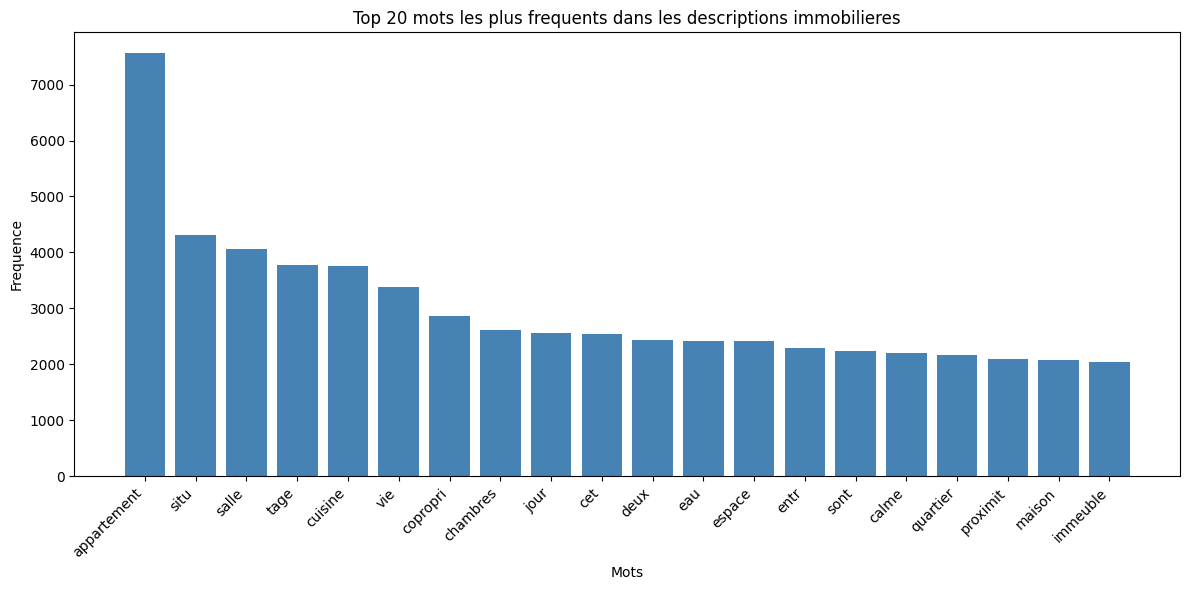

Graphique sauvegarde


In [7]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(top50_pd['mot'][:20], top50_pd['count'][:20], color='steelblue')
ax.set_xlabel('Mots')
ax.set_ylabel('Frequence')
ax.set_title('Top 20 mots les plus frequents dans les descriptions immobilieres')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../notebooks/barplot_nlp.png', dpi=100)
plt.show()
print('Graphique sauvegarde')

## Etape 7 — Interpretation des resultats NLP

Les mots les plus frequents revelent :
- **Attributs positifs** : calme, lumineux, vue, exclusivit
- **Equipements** : terrasse, balcon, parking, garage, cave
- **Localisation** : quartier, proche, commerces
- **Type de bien** : appartement, maison, studio, duplex

Ces 50 mots serviront de **features binaires** (presence/absence) pour le pipeline ML.

In [8]:
# Récupérer la liste des mots pour le notebook ML
TOP50_FEATURES = []
for row in top50_df.collect():
    TOP50_FEATURES.append(row['mot'])

print('Top 50 mots (à réutiliser dans le notebook 04) :')
print(TOP50_FEATURES)
spark.stop()

Top 50 mots (à réutiliser dans le notebook 04) :
['appartement', 'situ', 'salle', 'tage', 'cuisine', 'vie', 'copropri', 'chambres', 'jour', 'cet', 'deux', 'eau', 'espace', 'entr', 'sont', 'calme', 'quartier', 'proximit', 'maison', 'immeuble', 'immobilier', 'sidence', 'expos', 'chambre', 'lumineux', 'commerces', 'terrasse', 'quip', 'rue', 'ascenseur', 'propose', 'ind', 'offre', 'lots', 'compose', 'honoraires', 'place', 'agence', 'charges', 'jardin', 'ainsi', 'charge', 'balcon', 'france', 'rement', 'vue', 'bordeaux', 'pied', 'agr', 'offrant']
